In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

In [2]:
import pandas as pd
df = pd.read_excel("Survey_Response.xlsx")
df.head()


,Timestamp,User Name,Total Work Experience,How often do you use AI tools at work?,Which tasks do you use AI tools for at work?,How much time do you save on average per day by using AI tools?,How much faster can you complete tasks using AI Tools?,How much has AI tools reduced workload and efforts needed to finish tasks?,AI tools helps to understand and solve real world- related problems more easily,How much has AI tools helped improve the accuracy of your work?,How concerned are you about data privacy when using AI tools?,How often do you feel uncertain about the accuracy or reliability of AI-generated results?,How difficult do you find using AI tools due to limited skills or knowledge?,"overall, are you satisfied with using AI tools at work?",Work location
0,2025-11-26 13:54:52.580,test1,2–5 years,Daily,Information gathering / research / brainstormi...,30–60 minutes,7,7,7.0,3,2,3.0,5.0,"Yes, I am satisfied",Bengaluru
1,2025-11-26 16:08:21.168,Ramesh M,5–10 years,Daily,Problem-solving / suggestions / decision support,2–3 hours,9,9,9.0,9,10,9.0,0.0,"Yes, I am satisfied",Bengaluru
2,2025-11-26 16:27:51.415,Midhun Manoj,5–10 years,Daily,Information gathering / research / brainstormi...,1–2 hours,9,6,7.0,6,10,8.0,0.0,"Yes, I am satisfied",Saudi Arabia
3,2025-11-26 16:32:04.725,Mohan,2–5 years,Daily,Information gathering / research / brainstormi...,30–60 minutes,8,8,8.0,8,8,8.0,9.0,"Yes, I am satisfied",Bengaluru
4,2025-11-26 16:42:15.303,NaN,2–5 years,Weekly,Information gathering / research / brainstormi...,Less than 30 minutes,3,2,3.0,1,10,10.0,0.0,"No, I am not satisfied",Bengaluru


# Data Cleaning

In [3]:
df.columns

Index(['Timestamp', 'User Name', '  Total Work Experience  ',
       ' How often do you use AI tools at work?  ',
       'Which tasks do you use AI tools for at work?',
       'How much time do you save on average per day by using AI tools?',
       'How much faster can you complete tasks using AI Tools?',
       'How much has AI tools reduced workload and efforts needed to finish tasks?',
       'AI tools helps to understand and solve real world- related problems more easily',
       'How much has AI tools helped improve the accuracy of your work?',
       'How concerned are you about data privacy when using AI tools?',
       'How often do you feel uncertain about the accuracy or reliability of AI-generated results?  ',
       'How difficult do you find using AI tools due to limited skills or knowledge?  ',
       'overall, are you satisfied with using AI tools at work? ',
       'Work location'],
      dtype='object')

In [4]:
df = df.rename(columns={

    "Timestamp": "Timestamp",

    "User Name": "Respondent_Name",

    "  Total Work Experience  ": "Experience_Level",

    " How often do you use AI tools at work?  ": "Usage_Frequency",

    "Which tasks do you use AI tools for at work?": "Primary_Use_Cases",

    "How much time do you save on average per day by using AI tools?": "Daily_Time_Saved",

    "How much faster can you complete tasks using AI Tools?": "Productivity_Score",

    "How much has AI tools reduced workload and efforts needed to finish tasks?": "Workload_Reduction_Score",

    "AI tools helps to understand and solve real world- related problems more easily": "Problem_Solving_Score",

    "How much has AI tools helped improve the accuracy of your work?": "Accuracy_Score",

    "How concerned are you about data privacy when using AI tools?": "Data_Privacy_Concern_Score",

    "How often do you feel uncertain about the accuracy or reliability of AI-generated results?  ": "Uncertainty_Score",

    "How difficult do you find using AI tools due to limited skills or knowledge?  ": "Skill_Difficulty_Score",

    "overall, are you satisfied with using AI tools at work? ": "Overall_Satisfaction",

    "Work location": "Location"
})


In [5]:
df.columns

Index(['Timestamp', 'Respondent_Name', 'Experience_Level', 'Usage_Frequency',
       'Primary_Use_Cases', 'Daily_Time_Saved', 'Productivity_Score',
       'Workload_Reduction_Score', 'Problem_Solving_Score', 'Accuracy_Score',
       'Data_Privacy_Concern_Score', 'Uncertainty_Score',
       'Skill_Difficulty_Score', 'Overall_Satisfaction', 'Location'],
      dtype='object')

In [6]:
df["Overall_Satisfaction"] = df["Overall_Satisfaction"].map({"Yes, I am satisfied": 'Yes', "No, I am not satisfied": 'No'})

In [7]:
df.head()

,Timestamp,Respondent_Name,Experience_Level,Usage_Frequency,Primary_Use_Cases,Daily_Time_Saved,Productivity_Score,Workload_Reduction_Score,Problem_Solving_Score,Accuracy_Score,Data_Privacy_Concern_Score,Uncertainty_Score,Skill_Difficulty_Score,Overall_Satisfaction,Location
0,2025-11-26 13:54:52.580,test1,2–5 years,Daily,Information gathering / research / brainstormi...,30–60 minutes,7,7,7.0,3,2,3.0,5.0,Yes,Bengaluru
1,2025-11-26 16:08:21.168,Ramesh M,5–10 years,Daily,Problem-solving / suggestions / decision support,2–3 hours,9,9,9.0,9,10,9.0,0.0,Yes,Bengaluru
2,2025-11-26 16:27:51.415,Midhun Manoj,5–10 years,Daily,Information gathering / research / brainstormi...,1–2 hours,9,6,7.0,6,10,8.0,0.0,Yes,Saudi Arabia
3,2025-11-26 16:32:04.725,Mohan,2–5 years,Daily,Information gathering / research / brainstormi...,30–60 minutes,8,8,8.0,8,8,8.0,9.0,Yes,Bengaluru
4,2025-11-26 16:42:15.303,NaN,2–5 years,Weekly,Information gathering / research / brainstormi...,Less than 30 minutes,3,2,3.0,1,10,10.0,0.0,No,Bengaluru


In [8]:
df.shape

(113, 15)

In [9]:
# Check total missing values in each column
print("Missing values per column:")
print(df.isna().sum())



Missing values per column:
Timestamp                      0
Respondent_Name               10
Experience_Level               0
Usage_Frequency                0
Primary_Use_Cases              0
Daily_Time_Saved               0
Productivity_Score             0
Workload_Reduction_Score       0
Problem_Solving_Score          1
Accuracy_Score                 0
Data_Privacy_Concern_Score     0
Uncertainty_Score              3
Skill_Difficulty_Score         1
Overall_Satisfaction           0
Location                       0
dtype: int64


In [10]:
# Replace missing names with NA
df["Respondent_Name"] = df["Respondent_Name"].fillna("NA")

# Impute numeric score columns using mean
num_cols = ["Problem_Solving_Score", "Uncertainty_Score", "Skill_Difficulty_Score"]
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [11]:
print(df.isna().sum())


Timestamp                     0
Respondent_Name               0
Experience_Level              0
Usage_Frequency               0
Primary_Use_Cases             0
Daily_Time_Saved              0
Productivity_Score            0
Workload_Reduction_Score      0
Problem_Solving_Score         0
Accuracy_Score                0
Data_Privacy_Concern_Score    0
Uncertainty_Score             0
Skill_Difficulty_Score        0
Overall_Satisfaction          0
Location                      0
dtype: int64


In [12]:
# Convert column to lowercase for easier matching
df["Primary_Use_Cases"] = df["Primary_Use_Cases"].astype(str).str.lower()

# Dictionary of keywords and column names
usecase_keywords = {
    "information": "UseCase_Information_Research",
    "writing": "UseCase_Writing_Support",
    "document": "UseCase_Document_Creation",
    "media": "UseCase_Media_Assistance",
    "technical": "UseCase_Technical_Assistance",
    "problem": "UseCase_Problem_Solving",
    "other": "UseCase_Other"
}

# Create binary columns (0/1)
for keyword, col in usecase_keywords.items():
    df[col] = df["Primary_Use_Cases"].str.contains(keyword, na=False).astype(int)


In [13]:
# Standardize non-disclosed respondent names
df['Respondent_Name'] = df['Respondent_Name'].replace(
    ['NA', 'Na', 'na', 'N/A', 'n/a'],
    'Not Provided'
)



In [14]:
df.head()

,Timestamp,Respondent_Name,Experience_Level,Usage_Frequency,Primary_Use_Cases,Daily_Time_Saved,Productivity_Score,Workload_Reduction_Score,Problem_Solving_Score,Accuracy_Score,...,Skill_Difficulty_Score,Overall_Satisfaction,Location,UseCase_Information_Research,UseCase_Writing_Support,UseCase_Document_Creation,UseCase_Media_Assistance,UseCase_Technical_Assistance,UseCase_Problem_Solving,UseCase_Other
0,2025-11-26 13:54:52.580,test1,2–5 years,Daily,information gathering / research / brainstormi...,30–60 minutes,7,7,7.0,3,...,5.0,Yes,Bengaluru,1,0,1,1,0,0,0
1,2025-11-26 16:08:21.168,Ramesh M,5–10 years,Daily,problem-solving / suggestions / decision support,2–3 hours,9,9,9.0,9,...,0.0,Yes,Bengaluru,0,0,0,0,0,1,0
2,2025-11-26 16:27:51.415,Midhun Manoj,5–10 years,Daily,information gathering / research / brainstormi...,1–2 hours,9,6,7.0,6,...,0.0,Yes,Saudi Arabia,1,1,1,0,1,0,0
3,2025-11-26 16:32:04.725,Mohan,2–5 years,Daily,information gathering / research / brainstormi...,30–60 minutes,8,8,8.0,8,...,9.0,Yes,Bengaluru,1,0,0,0,0,0,0
4,2025-11-26 16:42:15.303,Not Provided,2–5 years,Weekly,information gathering / research / brainstormi...,Less than 30 minutes,3,2,3.0,1,...,0.0,No,Bengaluru,1,0,0,0,1,0,0


PHASE 1: DATASET STRUCTURE & QUALITY

In [15]:
# Dataset shape
print("Dataset Shape (Rows, Columns):")
print(df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Dataset information
print("\nDataset Information:")
df.info()


Dataset Shape (Rows, Columns):
(113, 22)

Column Names:
['Timestamp', 'Respondent_Name', 'Experience_Level', 'Usage_Frequency', 'Primary_Use_Cases', 'Daily_Time_Saved', 'Productivity_Score', 'Workload_Reduction_Score', 'Problem_Solving_Score', 'Accuracy_Score', 'Data_Privacy_Concern_Score', 'Uncertainty_Score', 'Skill_Difficulty_Score', 'Overall_Satisfaction', 'Location', 'UseCase_Information_Research', 'UseCase_Writing_Support', 'UseCase_Document_Creation', 'UseCase_Media_Assistance', 'UseCase_Technical_Assistance', 'UseCase_Problem_Solving', 'UseCase_Other']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Timestamp                     113 non-null    datetime64[ns]
 1   Respondent_Name               113 non-null    object        
 2   Experience_Level              113 non

# Descriptive statistics


In [16]:
# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(num_cols)

# Descriptive statistics
print("\nDescriptive Statistics for Numerical Columns:")
display(df[num_cols].describe().T)

Numerical Columns:
Index(['Productivity_Score', 'Workload_Reduction_Score',
       'Problem_Solving_Score', 'Accuracy_Score', 'Data_Privacy_Concern_Score',
       'Uncertainty_Score', 'Skill_Difficulty_Score'],
      dtype='object')

Descriptive Statistics for Numerical Columns:


,count,mean,std,min,25%,50%,75%,max
Productivity_Score,113.0,6.929204,2.141081,0.0,6.0,7.0,9.0,10.0
Workload_Reduction_Score,113.0,6.628319,2.155536,1.0,5.0,7.0,8.0,10.0
Problem_Solving_Score,113.0,6.584071,2.222955,0.0,5.0,7.0,8.0,10.0
Accuracy_Score,113.0,6.778761,2.218971,0.0,5.0,7.0,8.0,10.0
Data_Privacy_Concern_Score,113.0,7.176991,2.749124,0.0,6.0,8.0,10.0,10.0
Uncertainty_Score,113.0,6.194690,1.865372,0.0,5.0,6.0,8.0,10.0
Skill_Difficulty_Score,113.0,4.504425,2.921973,0.0,2.0,4.0,7.0,10.0


In [17]:
# Function to print value counts with percentage (NO DataFrame)
def print_value_counts_with_percentage(df, column):
    counts = df[column].value_counts()
    percentages = (counts / len(df)) * 100

    print(f"\n{column} Distribution:")
    print(f"{'Category':<30} {'Count':<10} {'Percentage (%)'}")

    for category, count in counts.items():
        print(f"{str(category):<30} {count:<10} {percentages[category]:.2f}")


# Identify categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# Columns to exclude
exclude_cols = ['Respondent_Name', 'Primary_Use_Cases', 'Location']

# Final categorical columns for analysis
final_cat_cols = [col for col in cat_cols if col not in exclude_cols]

print("Categorical Columns Considered for Analysis:")
print(final_cat_cols)

# Loop through each categorical column
for col in final_cat_cols:
    print_value_counts_with_percentage(df, col)


Categorical Columns Considered for Analysis:
['Experience_Level', 'Usage_Frequency', 'Daily_Time_Saved', 'Overall_Satisfaction']

Experience_Level Distribution:
Category                       Count      Percentage (%)
2–5 years                      34         30.09
5–10 years                     32         28.32
10–15 years                    23         20.35
0–2 years                      15         13.27
15–20 years                    7          6.19
20+ years                      2          1.77

Usage_Frequency Distribution:
Category                       Count      Percentage (%)
Daily                          70         61.95
Weekly                         31         27.43
Monthly                        6          5.31
Rarely                         5          4.42
Never                          1          0.88

Daily_Time_Saved Distribution:
Category                       Count      Percentage (%)
30–60 minutes                  39         34.51
Less than 30 minutes           37 

In [18]:
# Identify numerical columns
num_cols = df.select_dtypes(include=['int64', 'int32', 'float64']).columns

print("Numerical Columns Considered for Analysis:")
print(num_cols.tolist())


Numerical Columns Considered for Analysis:
['Productivity_Score', 'Workload_Reduction_Score', 'Problem_Solving_Score', 'Accuracy_Score', 'Data_Privacy_Concern_Score', 'Uncertainty_Score', 'Skill_Difficulty_Score', 'UseCase_Information_Research', 'UseCase_Writing_Support', 'UseCase_Document_Creation', 'UseCase_Media_Assistance', 'UseCase_Technical_Assistance', 'UseCase_Problem_Solving', 'UseCase_Other']


In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Productivity_Score,113.0,6.929204,2.141081,0.0,6.0,7.0,9.0,10.0
Workload_Reduction_Score,113.0,6.628319,2.155536,1.0,5.0,7.0,8.0,10.0
Problem_Solving_Score,113.0,6.584071,2.222955,0.0,5.0,7.0,8.0,10.0
Accuracy_Score,113.0,6.778761,2.218971,0.0,5.0,7.0,8.0,10.0
Data_Privacy_Concern_Score,113.0,7.176991,2.749124,0.0,6.0,8.0,10.0,10.0
Uncertainty_Score,113.0,6.194690,1.865372,0.0,5.0,6.0,8.0,10.0
Skill_Difficulty_Score,113.0,4.504425,2.921973,0.0,2.0,4.0,7.0,10.0
UseCase_Information_Research,113.0,0.433628,0.497783,0.0,0.0,0.0,1.0,1.0
UseCase_Writing_Support,113.0,0.353982,0.480334,0.0,0.0,0.0,1.0,1.0
UseCase_Document_Creation,113.0,0.203540,0.404424,0.0,0.0,0.0,0.0,1.0


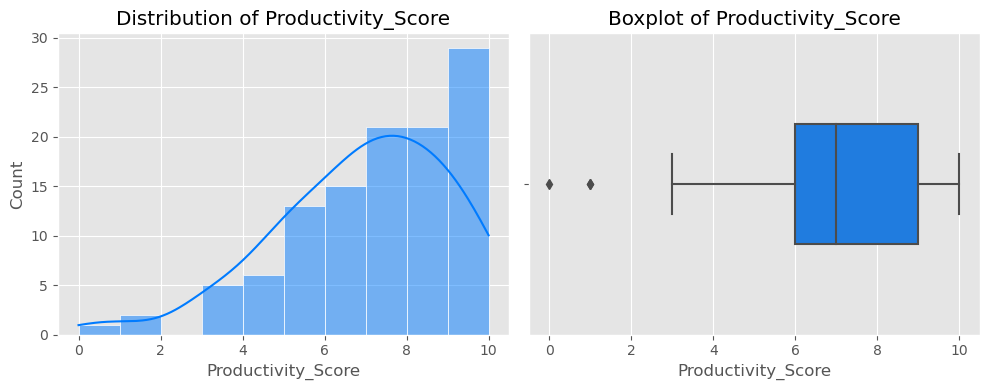

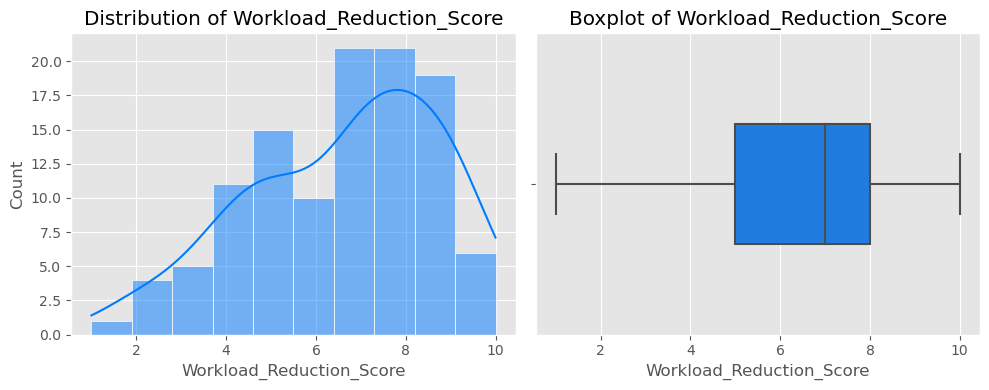

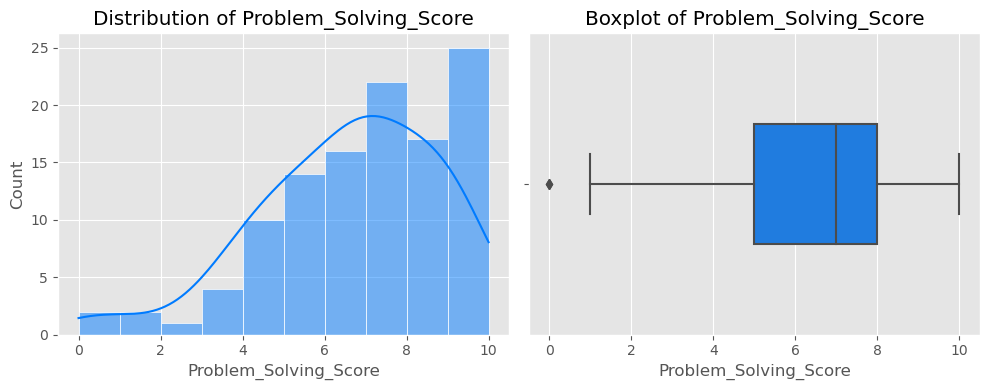

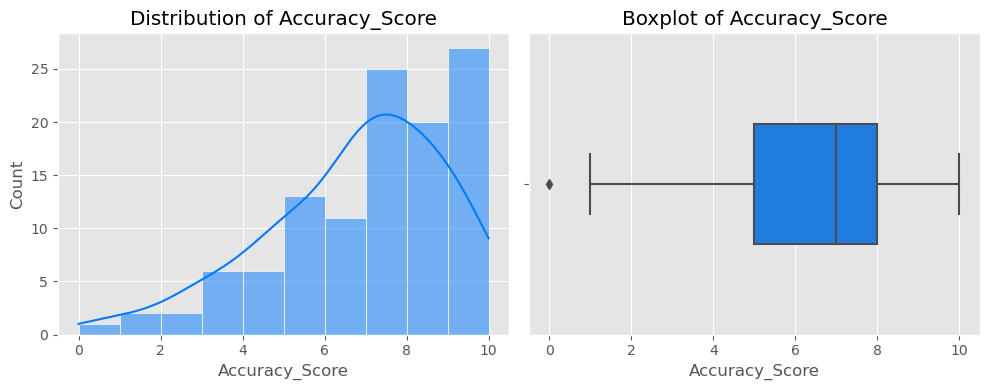

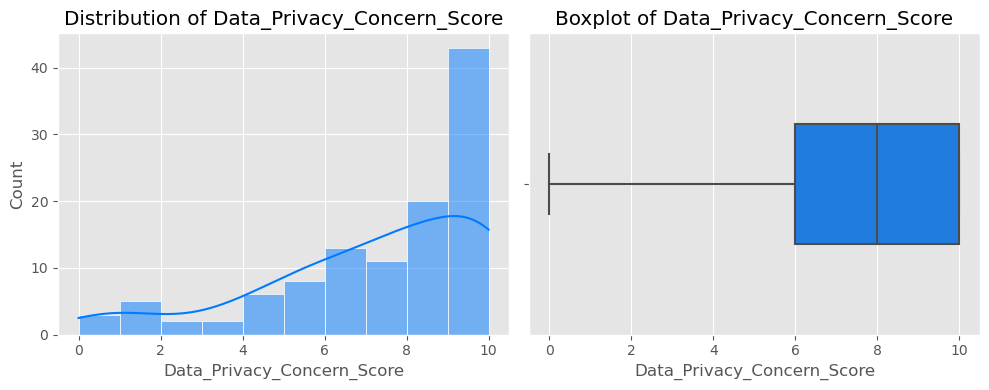

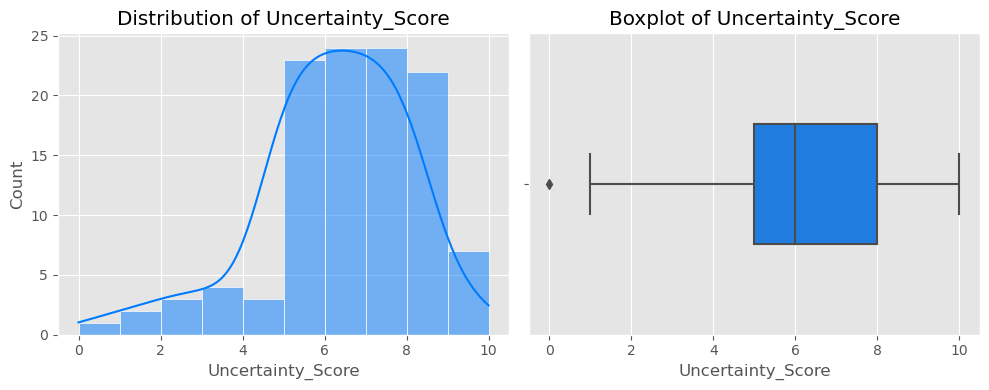

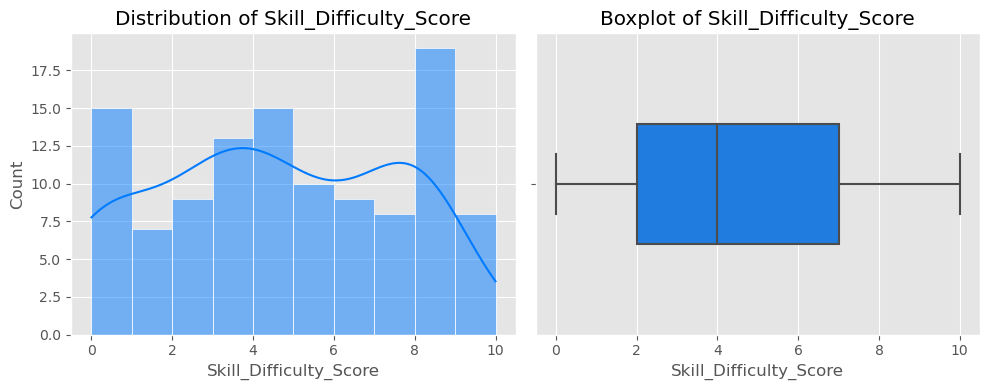

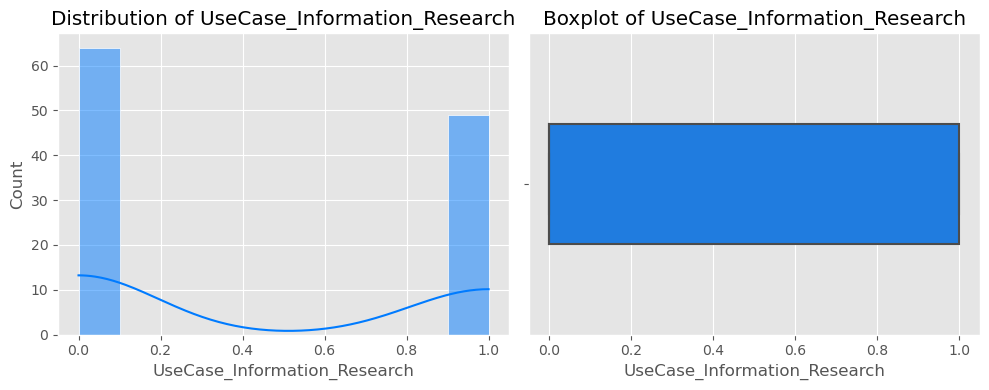

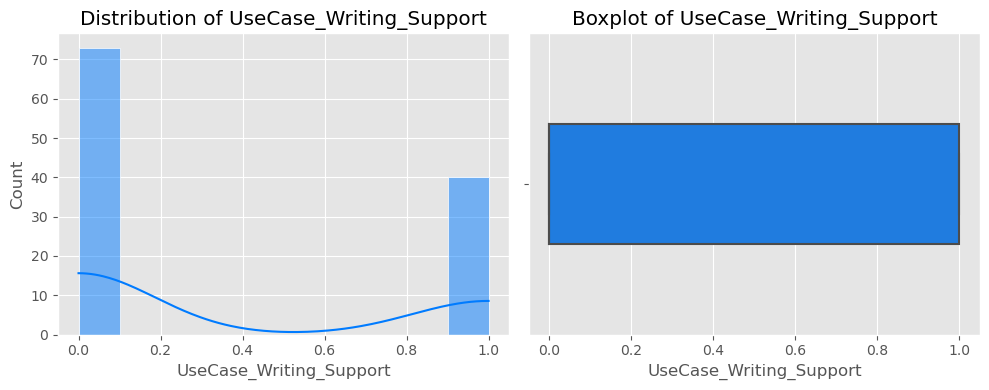

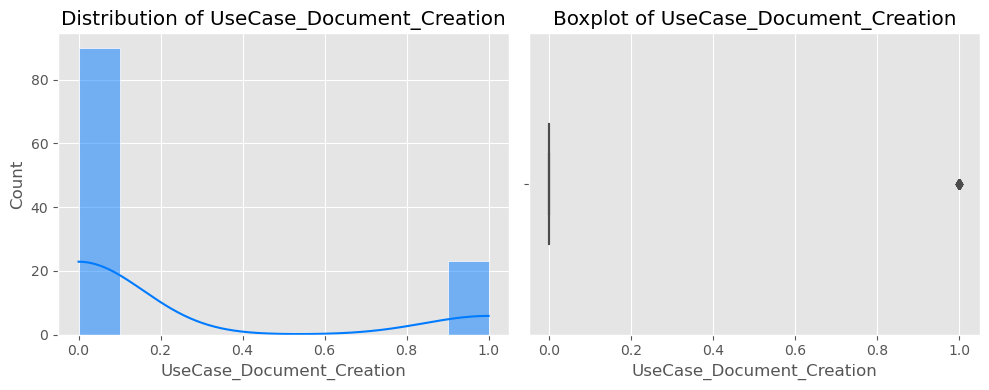

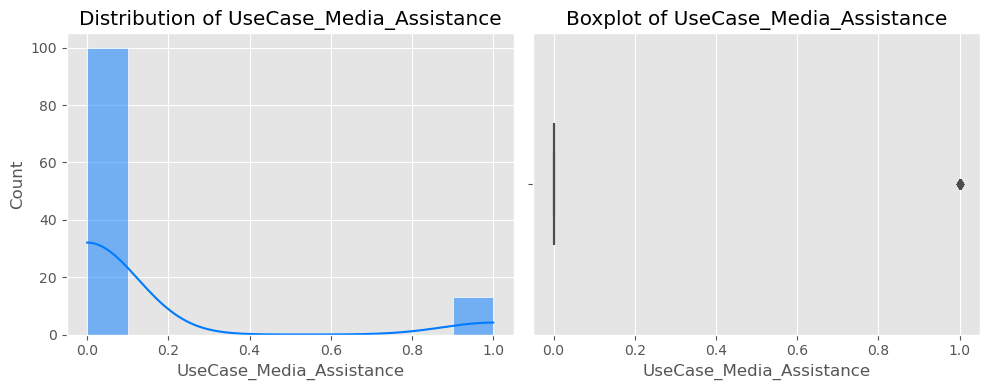

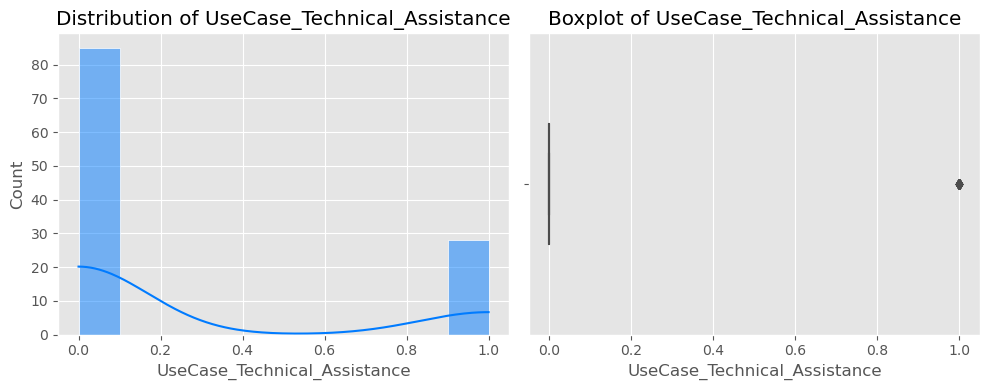

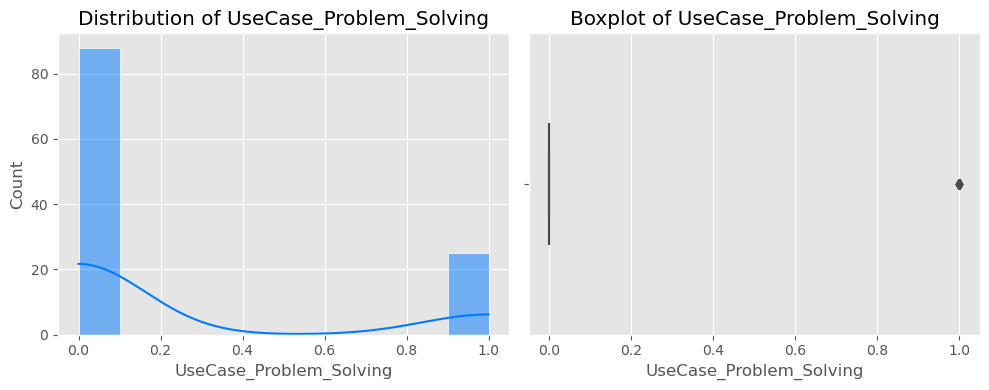

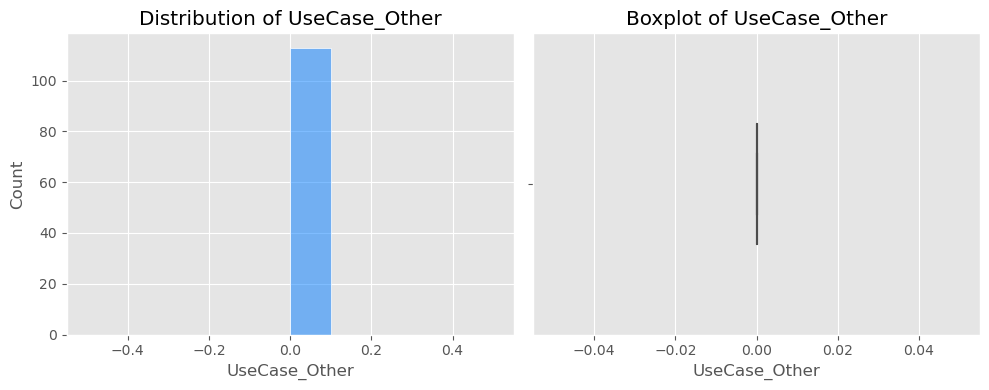

In [20]:
for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    sns.histplot(
        df[col],
        bins=10,
        kde=True,
        color="#007BFF",
        edgecolor="white",
        ax=axes[0]
    )
    axes[0].set_title(f'Distribution of {col}')
    axes[0].set_xlabel(col)

    sns.boxplot(
        x=df[col],
        color="#007BFF",
        width=0.4,
        ax=axes[1]
    )
    axes[1].set_title(f'Boxplot of {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()


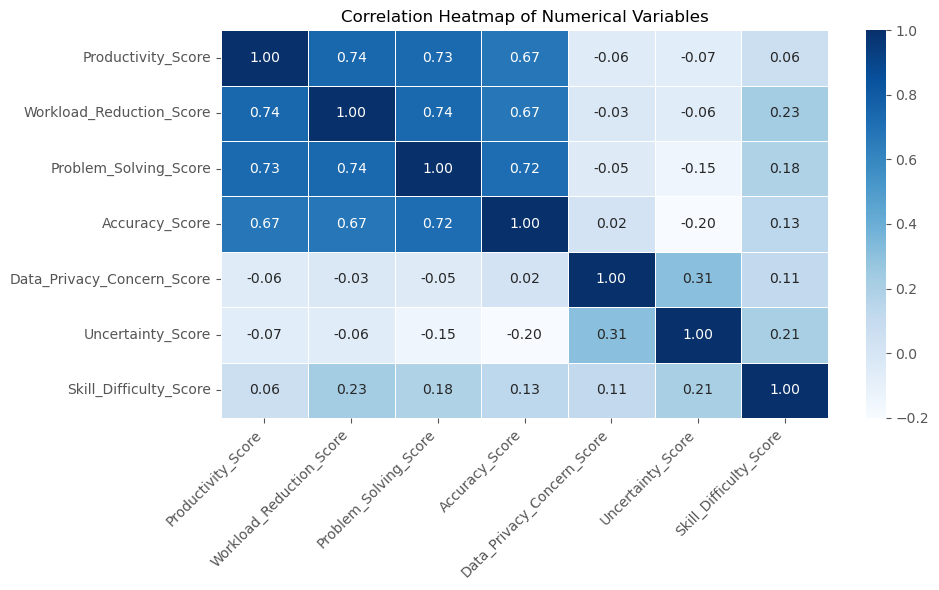

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select numerical columns relevant for correlation
num_cols = [
    'Productivity_Score',
    'Workload_Reduction_Score',
    'Problem_Solving_Score',
    'Accuracy_Score',
    'Data_Privacy_Concern_Score',
    'Uncertainty_Score',
    'Skill_Difficulty_Score'
]
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    cbar=True
)

plt.title("Correlation Heatmap of Numerical Variables", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


- **Productivity**, **Workload Reduction**, **Problem Solving**, and **Accuracy** show strong positive correlations, indicating these performance factors are closely related and improve together.  
- **Data Privacy Concern** and **Uncertainty** have weak or negative correlations with core performance metrics, suggesting they influence user perception independently of productivity.


In [22]:
import pandas as pd

# Function to create crosstab with percentage
def categorical_bivariate_analysis(df, col1, col2):
    crosstab = pd.crosstab(df[col1], df[col2])
    percentage = pd.crosstab(df[col1], df[col2], normalize='index') * 100

    print(f"\nCrosstab: {col1} vs {col2}")
    print(crosstab)

    print(f"\nPercentage Distribution (%): {col1} vs {col2}")
    print(percentage.round(2))


In [23]:
categorical_bivariate_analysis(df, 'Experience_Level', 'Overall_Satisfaction')
categorical_bivariate_analysis(df, 'Usage_Frequency', 'Overall_Satisfaction')



Crosstab: Experience_Level vs Overall_Satisfaction
Overall_Satisfaction  No  Yes
Experience_Level             
0–2 years              1   14
10–15 years            6   17
15–20 years            3    4
20+ years              0    2
2–5 years              2   32
5–10 years             5   27

Percentage Distribution (%): Experience_Level vs Overall_Satisfaction
Overall_Satisfaction     No     Yes
Experience_Level                   
0–2 years              6.67   93.33
10–15 years           26.09   73.91
15–20 years           42.86   57.14
20+ years              0.00  100.00
2–5 years              5.88   94.12
5–10 years            15.62   84.38

Crosstab: Usage_Frequency vs Overall_Satisfaction
Overall_Satisfaction  No  Yes
Usage_Frequency              
Daily                  6   64
Monthly                2    4
Never                  0    1
Rarely                 3    2
Weekly                 6   25

Percentage Distribution (%): Usage_Frequency vs Overall_Satisfaction
Overall_Satisfacti

- Satisfaction is consistently high across experience levels, especially for **2–5 years (94%)** and **0–2 years (93%)**, while dissatisfaction increases slightly in the **10–15 years** and **15–20 years** groups.  
- Usage frequency shows a strong pattern: **daily users are highly satisfied (91%)**, whereas **rare users show the lowest satisfaction (40%)**, indicating frequent usage is closely linked to positive experience.


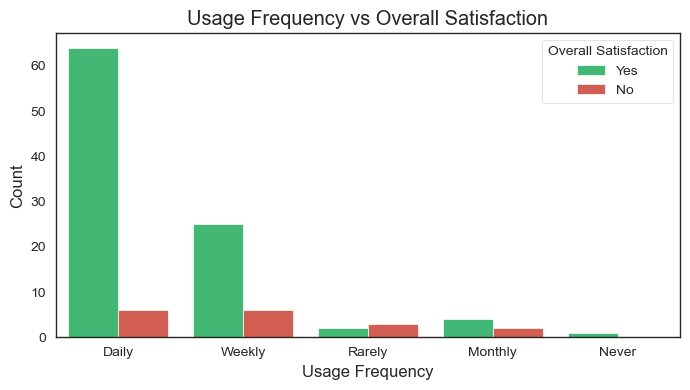

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean style (no grid)
sns.set_style("white")

plt.figure(figsize=(7, 4))

sns.countplot(
    data=df,
    x='Usage_Frequency',
    hue='Overall_Satisfaction',
    hue_order=['Yes', 'No'],             
    palette={'Yes': '#2ECC71', 'No': '#E74C3C'}  
)

plt.title('Usage Frequency vs Overall Satisfaction')
plt.xlabel('Usage Frequency')
plt.ylabel('Count')
plt.legend(title='Overall Satisfaction')
plt.tight_layout()
plt.show()


- Users who engage with the AI tool **daily or weekly** show the highest levels of satisfaction, indicating frequent usage is strongly associated with positive experience.  
- Infrequent users (**rarely or never**) have lower satisfaction counts, suggesting limited usage may reduce perceived value.


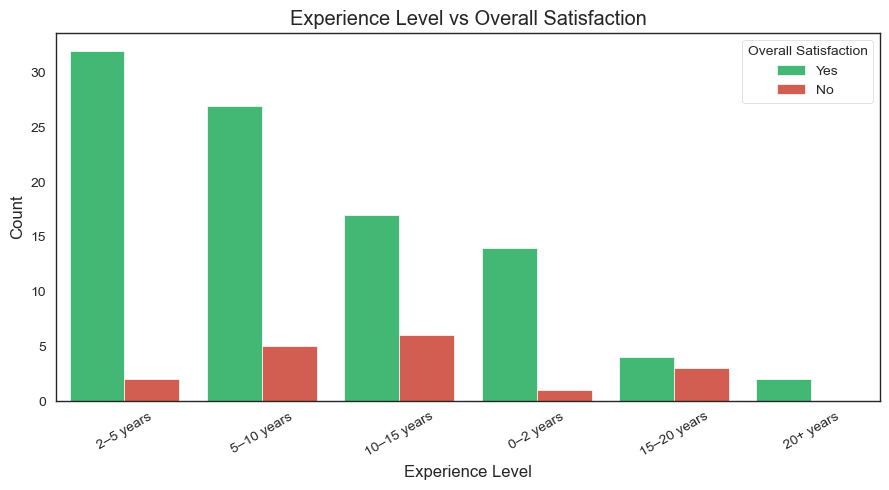

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clean style
sns.set_style("white")

plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x='Experience_Level',
    hue='Overall_Satisfaction',
    hue_order=['Yes', 'No'],
    palette={'Yes': '#2ECC71', 'No': '#E74C3C'}
)

plt.title('Experience Level vs Overall Satisfaction')
plt.xlabel('Experience Level')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='Overall Satisfaction')
plt.tight_layout()
plt.show()


- High satisfaction is observed across all experience levels, with the **2–5 years** and **5–10 years** groups showing the largest number of satisfied users.  
- Dissatisfaction remains relatively low overall but is slightly higher in the **10–15 years** and **15–20 years** experience groups.


# Data Analysis

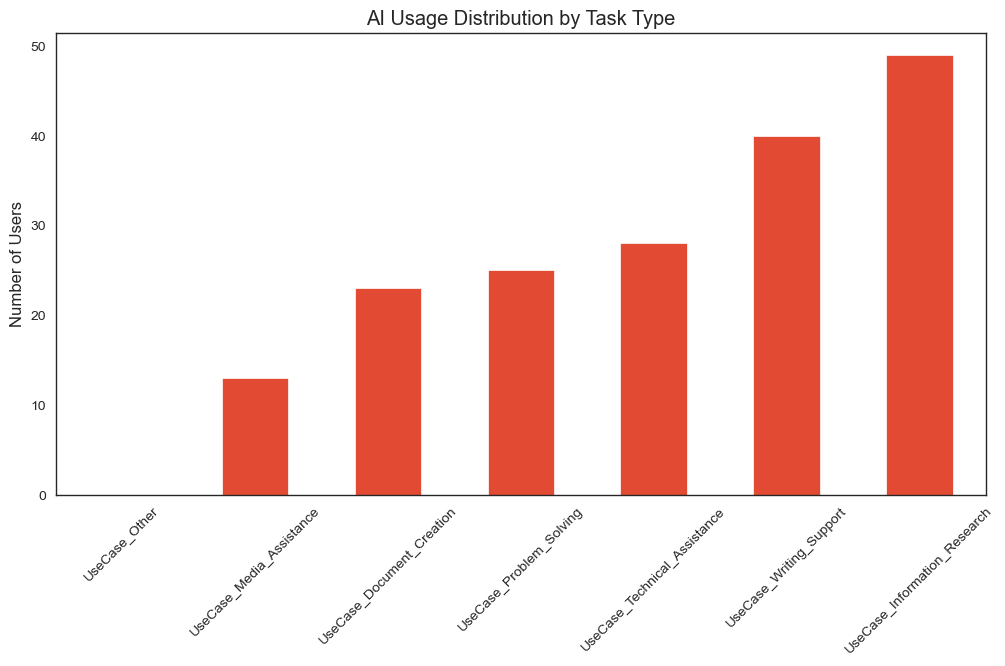

In [26]:
import matplotlib.pyplot as plt

usecase_cols = [
    "UseCase_Information_Research",
    "UseCase_Writing_Support",
    "UseCase_Document_Creation",
    "UseCase_Media_Assistance",
    "UseCase_Technical_Assistance",
    "UseCase_Problem_Solving",
    "UseCase_Other"
]

plt.figure(figsize=(12,6))
df[usecase_cols].sum().sort_values().plot(kind="bar")
plt.title("AI Usage Distribution by Task Type")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)
plt.show()


- **Information Research** and **Writing Support** are the most common AI use cases, showing users primarily rely on AI for knowledge gathering and content assistance.  
- **Technical Assistance** and **Problem Solving** also see strong usage, while **Media Assistance** and **Other** use cases are less frequently used.
``


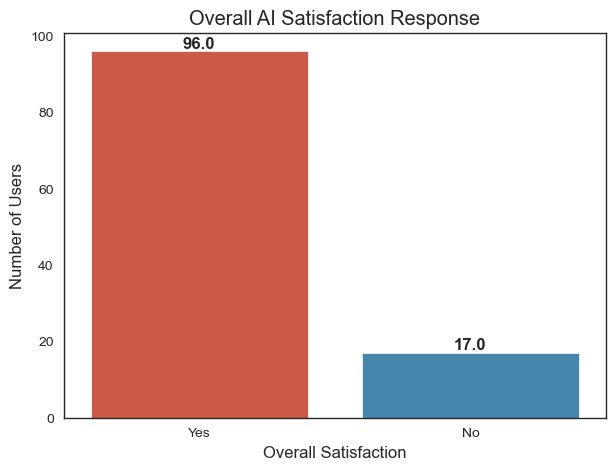

In [27]:
plt.figure(figsize=(7,5))
ax = sns.countplot(x='Overall_Satisfaction', data=df)

# Add count labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title("Overall AI Satisfaction Response")
plt.ylabel("Number of Users")
plt.xlabel("Overall Satisfaction")
plt.show()

- The majority of users (**96**) report being satisfied with the AI tool, indicating a strong overall positive response.  
- A smaller group (**17 users**) report dissatisfaction, suggesting limited but notable areas for improvement.


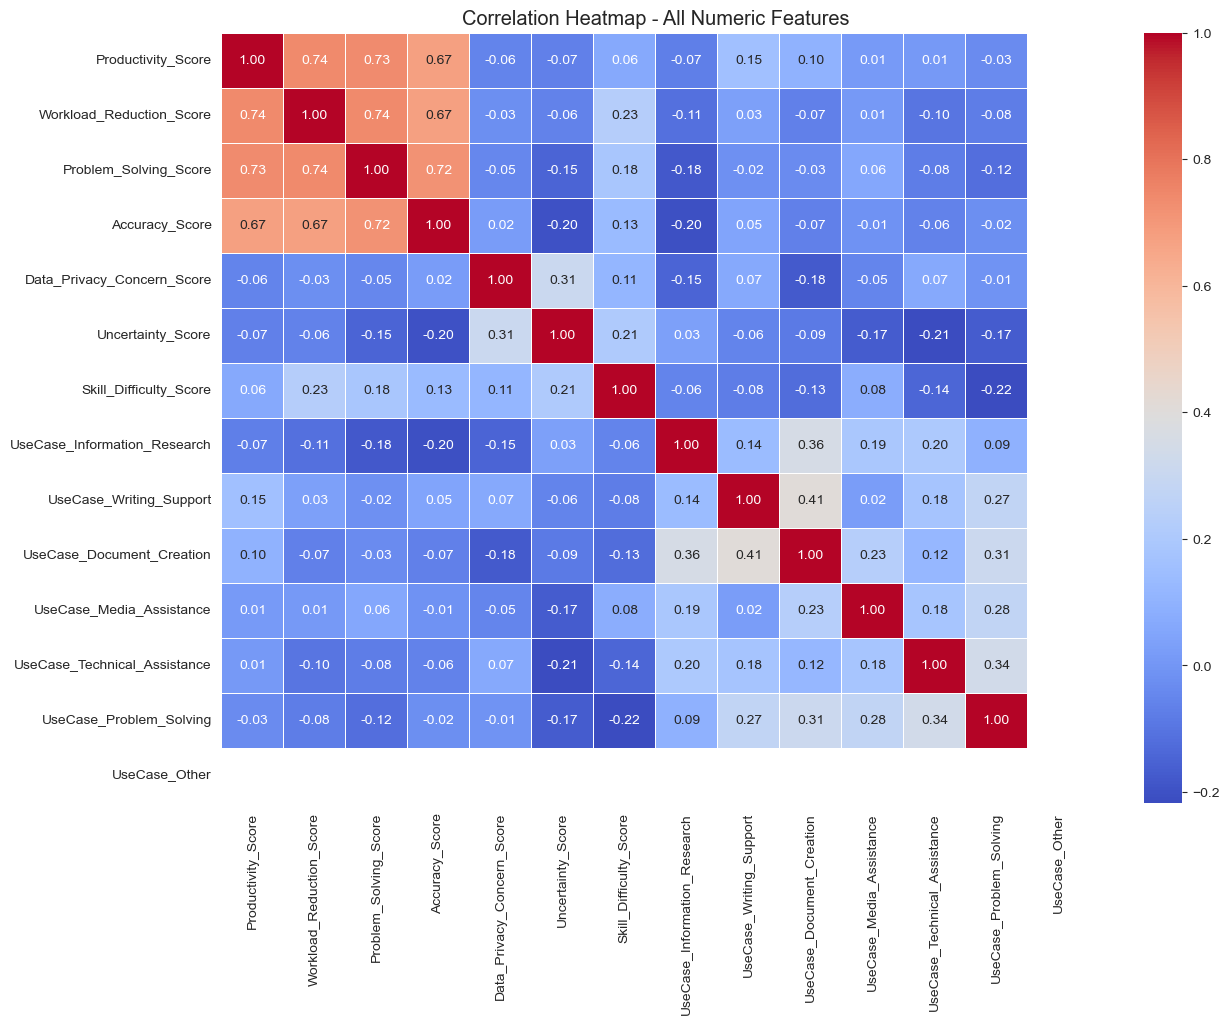

In [28]:
plt.figure(figsize=(14,10))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)
plt.title("Correlation Heatmap - All Numeric Features")
plt.show()


- **Productivity**, **Workload Reduction**, **Problem Solving**, and **Accuracy** are strongly positively correlated, showing these performance-related factors move together and reinforce overall effectiveness.  
- **Uncertainty** and **Data Privacy Concern** show weak or negative correlations with core performance scores, indicating they influence user perception differently from productivity-driven factors.


In [29]:
df.columns

Index(['Timestamp', 'Respondent_Name', 'Experience_Level', 'Usage_Frequency',
       'Primary_Use_Cases', 'Daily_Time_Saved', 'Productivity_Score',
       'Workload_Reduction_Score', 'Problem_Solving_Score', 'Accuracy_Score',
       'Data_Privacy_Concern_Score', 'Uncertainty_Score',
       'Skill_Difficulty_Score', 'Overall_Satisfaction', 'Location',
       'UseCase_Information_Research', 'UseCase_Writing_Support',
       'UseCase_Document_Creation', 'UseCase_Media_Assistance',
       'UseCase_Technical_Assistance', 'UseCase_Problem_Solving',
       'UseCase_Other'],
      dtype='object')

In [30]:
df = df.drop(columns=[
    "Timestamp",
    "Respondent_Name",
    "Primary_Use_Cases",
    "Location"
])


In [31]:
df.head()

,Experience_Level,Usage_Frequency,Daily_Time_Saved,Productivity_Score,Workload_Reduction_Score,Problem_Solving_Score,Accuracy_Score,Data_Privacy_Concern_Score,Uncertainty_Score,Skill_Difficulty_Score,Overall_Satisfaction,UseCase_Information_Research,UseCase_Writing_Support,UseCase_Document_Creation,UseCase_Media_Assistance,UseCase_Technical_Assistance,UseCase_Problem_Solving,UseCase_Other
0,2–5 years,Daily,30–60 minutes,7,7,7.0,3,2,3.0,5.0,Yes,1,0,1,1,0,0,0
1,5–10 years,Daily,2–3 hours,9,9,9.0,9,10,9.0,0.0,Yes,0,0,0,0,0,1,0
2,5–10 years,Daily,1–2 hours,9,6,7.0,6,10,8.0,0.0,Yes,1,1,1,0,1,0,0
3,2–5 years,Daily,30–60 minutes,8,8,8.0,8,8,8.0,9.0,Yes,1,0,0,0,0,0,0
4,2–5 years,Weekly,Less than 30 minutes,3,2,3.0,1,10,10.0,0.0,No,1,0,0,0,1,0,0


In [32]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols_to_encode = ["Experience_Level", "Usage_Frequency", "Daily_Time_Saved",'Overall_Satisfaction']

for col in cols_to_encode:
    df[col] = le.fit_transform(df[col])

print(df[cols_to_encode].head())


   Experience_Level  Usage_Frequency  Daily_Time_Saved  Overall_Satisfaction
0                 4                0                 2                     1
1                 5                0                 1                     1
2                 5                0                 0                     1
3                 4                0                 2                     1
4                 4                4                 4                     0


In [33]:
df.head()

,Experience_Level,Usage_Frequency,Daily_Time_Saved,Productivity_Score,Workload_Reduction_Score,Problem_Solving_Score,Accuracy_Score,Data_Privacy_Concern_Score,Uncertainty_Score,Skill_Difficulty_Score,Overall_Satisfaction,UseCase_Information_Research,UseCase_Writing_Support,UseCase_Document_Creation,UseCase_Media_Assistance,UseCase_Technical_Assistance,UseCase_Problem_Solving,UseCase_Other
0,4,0,2,7,7,7.0,3,2,3.0,5.0,1,1,0,1,1,0,0,0
1,5,0,1,9,9,9.0,9,10,9.0,0.0,1,0,0,0,0,0,1,0
2,5,0,0,9,6,7.0,6,10,8.0,0.0,1,1,1,1,0,1,0,0
3,4,0,2,8,8,8.0,8,8,8.0,9.0,1,1,0,0,0,0,0,0
4,4,4,4,3,2,3.0,1,10,10.0,0.0,0,1,0,0,0,1,0,0


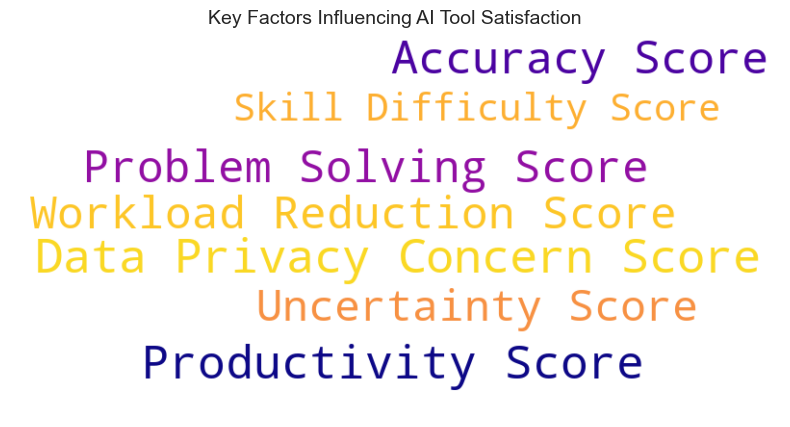

In [35]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

score_cols = [
    'Productivity_Score',
    'Workload_Reduction_Score',
    'Problem_Solving_Score',
    'Accuracy_Score',
    'Data_Privacy_Concern_Score',
    'Uncertainty_Score',
    'Skill_Difficulty_Score'
]

score_freq = df[score_cols].mean().to_dict()

score_freq = {
    k.replace("_", " "): round(v, 2)
    for k, v in score_freq.items()
}

wc = WordCloud(
    width=800,
    height=400,
    background_color="white",
    colormap="plasma"
).generate_from_frequencies(score_freq)

plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Key Factors Influencing AI Tool Satisfaction", fontsize=14)
plt.show()


- **Accuracy**, **Problem Solving**, and **Productivity** are the most prominent factors, indicating they strongly influence overall AI tool satisfaction.  
- Concerns like **Data Privacy**, **Workload Reduction**, and **Skill Difficulty** also matter, but play a comparatively secondary role in user satisfaction.


#  Machine Learning Model Development

In [36]:
y = df["Overall_Satisfaction"]
X = df.drop(columns=["Overall_Satisfaction"])

In [37]:
X.columns

Index(['Experience_Level', 'Usage_Frequency', 'Daily_Time_Saved',
       'Productivity_Score', 'Workload_Reduction_Score',
       'Problem_Solving_Score', 'Accuracy_Score', 'Data_Privacy_Concern_Score',
       'Uncertainty_Score', 'Skill_Difficulty_Score',
       'UseCase_Information_Research', 'UseCase_Writing_Support',
       'UseCase_Document_Creation', 'UseCase_Media_Assistance',
       'UseCase_Technical_Assistance', 'UseCase_Problem_Solving',
       'UseCase_Other'],
      dtype='object')

In [38]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (79, 17)
Test shape: (34, 17)


## Machine Learning Model Comparison

In [39]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# ---- Convert X to numpy (fix for KNN error) ----
Xtr = np.asarray(X_train, dtype=np.float64)
Xte = np.asarray(X_test, dtype=np.float64)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, solver="liblinear", random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB()
}

for name, model in models.items():
    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average="weighted")

    print(f"{name}:\n Accuracy = {acc:.4f}, F1 = {f1:.4f}\n")


Logistic Regression:
 Accuracy = 0.8529, F1 = 0.8260

Decision Tree:
 Accuracy = 0.7647, F1 = 0.7523

Random Forest:
 Accuracy = 0.8529, F1 = 0.8260

KNN:
 Accuracy = 0.7647, F1 = 0.7339

Naive Bayes:
 Accuracy = 0.5882, F1 = 0.6085



- **Logistic Regression** and **Random Forest** perform the best, both achieving the highest accuracy (**85.29%**) and F1-score (**0.826**), making them the most reliable models for this dataset.  
- **Decision Tree** and **KNN** show moderate performance, while **Naive Bayes** performs the weakest, indicating it may not capture the data patterns effectively.
`


In [41]:
log_reg = LogisticRegression(max_iter=1000, solver="liblinear",random_state = 42 )
log_reg.fit(X_train, y_train)

y_pred_log = log_reg.predict(X_test)

print("\n=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n", classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))


=== Logistic Regression Results ===
Accuracy: 0.8529411764705882

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.38      0.55         8
           1       0.84      1.00      0.91        26

    accuracy                           0.85        34
   macro avg       0.92      0.69      0.73        34
weighted avg       0.88      0.85      0.83        34

Confusion Matrix:
 [[ 3  5]
 [ 0 26]]


- Using the default threshold, the model achieves **85% accuracy** but shows **poor recall for class 0 (38%)**, missing most class-0 cases despite perfect precision.  
- The confusion matrix indicates the model is **biased toward class 1**, correctly predicting all class-1 samples but misclassifying many class-0 instances.


### Model Optimization 

In [53]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

lr = LogisticRegression(max_iter=3000, solver="liblinear", random_state=42)
lr.fit(X_train, y_train)

proba = lr.predict_proba(X_test)[:, 1]

best_t, best_score = None, -1
for t in np.arange(0.2, 0.81, 0.05):
    pred_t = (proba >= t).astype(int)
    cm = confusion_matrix(y_test, pred_t)
    # score = recall for class 0 (you can change this)
    if cm.shape == (2,2) and (cm[0,0] + cm[0,1]) > 0:
        recall_0 = cm[0,0] / (cm[0,0] + cm[0,1])
        if recall_0 > best_score:
            best_score = recall_0
            best_t = t

final_pred = (proba >= best_t).astype(int)

print("Best threshold for class 0 recall:", best_t)
print("Accuracy:", accuracy_score(y_test, final_pred))
print("\nClassification Report:\n", classification_report(y_test, final_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, final_pred))


Best threshold for class 0 recall: 0.7
Accuracy: 0.9117647058823529

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.75      0.80         8
           1       0.93      0.96      0.94        26

    accuracy                           0.91        34
   macro avg       0.89      0.86      0.87        34
weighted avg       0.91      0.91      0.91        34

Confusion Matrix:
 [[ 6  2]
 [ 1 25]]


- With a threshold of **0.7**, the model prioritizes **class 0 recall**, correctly identifying **6 out of 8** class-0 cases while keeping overall accuracy high (**91%**).  
- Class 1 performance remains strong (**96% recall, 94% F1**), showing the threshold adjustment improves class-0 detection without significantly harming class-1 predictions.


# Feature Importances

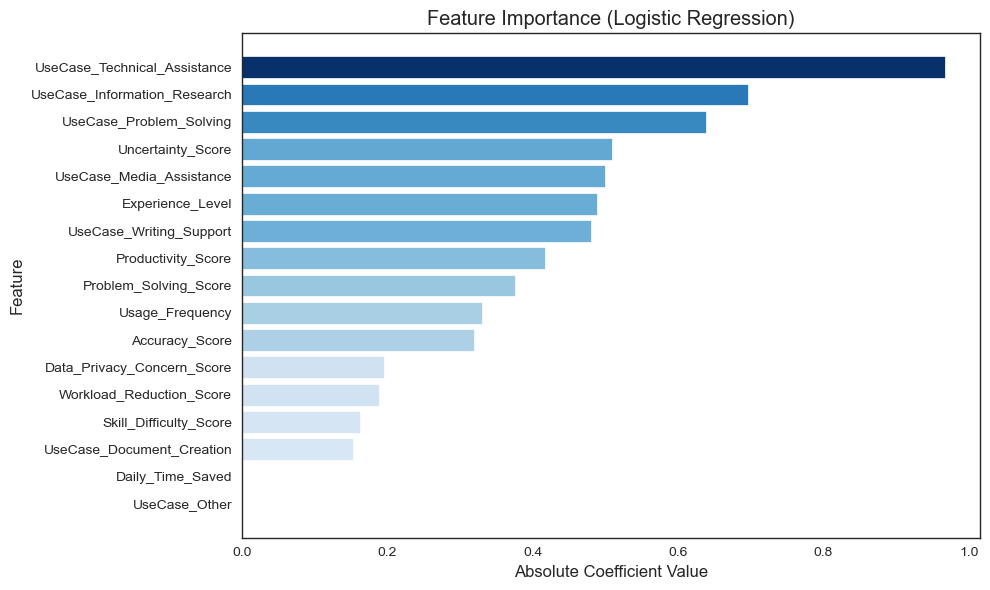

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Feature names
features = X_train.columns if hasattr(X_train, "columns") else range(X_train.shape[1])

# Importance from logistic regression
importance = np.abs(lr.coef_[0])

# DataFrame
imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values("Importance", ascending=False)

# Normalize for color mapping
colors = plt.cm.Blues(imp_df["Importance"] / imp_df["Importance"].max())

# Plot
plt.figure(figsize=(10, 6))
plt.barh(imp_df["Feature"], imp_df["Importance"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Absolute Coefficient Value")
plt.ylabel("Feature")
plt.title("Feature Importance (Logistic Regression)")
plt.tight_layout()
plt.show()


- **UseCase_Technical_Assistance**, **UseCase_Information_Research**, and **UseCase_Problem_Solving** have the highest influence, indicating these use cases are the strongest drivers of the model’s predictions.  
- Features such as **Daily_Time_Saved** and **UseCase_Other** show very low importance, meaning they contribute minimally to the final classification.


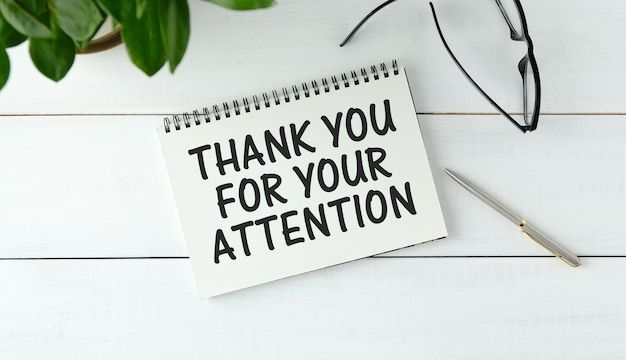